In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import io
import urllib.request

url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%206%20-%20Applications%20for%20Data%20Analysis/W6D5%20-%20Mini%20project/Mobile%20Price%20Classification.zip"

with urllib.request.urlopen(url) as response:
    zip_bytes = io.BytesIO(response.read())

with zipfile.ZipFile(zip_bytes) as z:
    with z.open("Mobile Price Classification/Mobile Price Classification/train.csv") as f:
        df = pd.read_csv(f)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (2000, 21)

Columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']


# Daily Challenge — Comprehensive Mobile Price Analysis

**Dataset:** Mobile Price Classification (2,000 phones, 21 features, target: `price_range`)

## 1. Data Loading and Exploration

In [4]:
print("Data types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nTarget variable distribution:")
print(df['price_range'].value_counts().sort_index())

print("\nDescriptive statistics:")
print(df.describe())

Data types:
 battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

Missing values:
 0

Target variable distribution:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

Descriptive statistics:
       battery_power       blue  clock_speed     dual_sim           fc  \
count    2000.000000  2000.0000  2000.000000  2000.000000  2000.000000   
mean     1238.518500     0.4950     1.522250     0.509500     4.309500   
std       439.418206     0.5001     0.816004     0.500035     4.341444   
mi

The dataset is pre-cleaned with no missing values, and `price_range` is perfectly balanced (500 phones per category — 0=low, 1=medium, 2=high, 3=very high cost). Several columns (`blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, `wifi`) are binary yes/no flags (0/1) rather than continuous measurements. One data quality concern: `px_height` has a minimum of 0, which is not physically possible for a real phone screen and will need investigation.

In [5]:
zero_height = (df['px_height'] == 0).sum()
print(f"Rows with px_height = 0: {zero_height} out of {len(df)} ({zero_height/len(df)*100:.2f}%)")

Rows with px_height = 0: 2 out of 2000 (0.10%)


Verified: only 2 out of 2,000 rows (0.10%) have `px_height = 0` — a negligible data quality issue, not worth correcting given its tiny scale relative to the dataset.

## 2. Data Cleaning and Preprocessing

No missing values were found, and all columns are already numeric (int64/float64) — no type conversion needed. The binary features (`blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, `wifi`) are already encoded as 0/1, which is the exact numerical format needed for analysis — no further categorical-to-numerical transformation is required, since this dataset was pre-processed for machine learning use.

## 3. Statistical Analysis with NumPy and SciPy

### Central Tendency, Variability, and Distribution Shape

In [6]:
numeric_features = ['battery_power', 'clock_speed', 'int_memory', 'mobile_wt', 'n_cores',
                     'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']

stats_summary = pd.DataFrame({
    'mean': df[numeric_features].mean(),
    'median': df[numeric_features].median(),
    'mode': df[numeric_features].mode().iloc[0],
    'range': df[numeric_features].max() - df[numeric_features].min(),
    'variance': df[numeric_features].var(),
    'std': df[numeric_features].std(),
    'skewness': df[numeric_features].apply(lambda x: stats.skew(x)),
    'kurtosis': df[numeric_features].apply(lambda x: stats.kurtosis(x))
})

print(stats_summary.round(2))

                  mean  median    mode   range    variance      std  skewness  \
battery_power  1238.52  1226.0   618.0  1497.0   193088.36   439.42      0.03   
clock_speed       1.52     1.5     0.5     2.5        0.67     0.82      0.18   
int_memory       32.05    32.0    27.0    62.0      329.27    18.15      0.06   
mobile_wt       140.25   141.0   182.0   120.0     1253.14    35.40      0.01   
n_cores           4.52     4.0     4.0     7.0        5.23     2.29      0.00   
px_height       645.11   564.0   347.0  1960.0   196941.41   443.78      0.67   
px_width       1251.52  1247.0   874.0  1498.0   186796.36   432.20      0.01   
ram            2124.21  2146.5  1229.0  3742.0  1176643.61  1084.73      0.01   
sc_h             12.31    12.0    17.0    14.0       17.75     4.21     -0.10   
sc_w              5.77     5.0     1.0    18.0       18.98     4.36      0.63   
talk_time        11.01    11.0     7.0    18.0       29.85     5.46      0.01   

               kurtosis  
b

Unlike previous real-world datasets analyzed this bootcamp (which showed strong positive skew), every feature here has near-zero skewness (0.00-0.67) and consistently negative kurtosis (~-1.2). This indicates values are spread nearly evenly across their range rather than clustering with extreme outliers — a strong signal that this dataset was synthetically generated for machine learning practice, deliberately avoiding the skew and outliers typical of real-world specs (which would cluster around common manufacturing standards like 4GB/8GB RAM tiers, not spread uniformly from 256-3998 MB).

In [7]:
ram_by_price = [df[df['price_range'] == p]['ram'] for p in sorted(df['price_range'].unique())]

f_value, p_value = stats.f_oneway(*ram_by_price)

print("H0: Average RAM is the same across all price ranges")
print("H1: Average RAM differs across at least one price range")
print()
for p in sorted(df['price_range'].unique()):
    print(f"Price range {p}: mean RAM = {df[df['price_range']==p]['ram'].mean():.1f} MB")

print(f"\nF-value: {f_value:.4f}")
print(f"P-value: {p_value:.10f}")

H0: Average RAM is the same across all price ranges
H1: Average RAM differs across at least one price range

Price range 0: mean RAM = 785.3 MB
Price range 1: mean RAM = 1679.5 MB
Price range 2: mean RAM = 2582.8 MB
Price range 3: mean RAM = 3449.2 MB

F-value: 3520.1108
P-value: 0.0000000000


RAM shows an extremely strong, statistically significant relationship with price range (F=3520.11, p≈0) — average RAM rises in a near-perfect staircase pattern (785 → 1680 → 2583 → 3449 MB) across the four price tiers. This is the strongest signal found so far in the dataset, strongly suggesting RAM is a primary driver of mobile phone price classification.

In [8]:
correlation, corr_p = stats.pearsonr(df['ram'], df['price_range'])
print(f"Correlation between RAM and price_range: {correlation:.4f} (p={corr_p:.10f})")

print("\nCorrelation of all features with price_range:")
correlations = df.drop('price_range', axis=1).apply(lambda x: stats.pearsonr(x, df['price_range'])[0])
print(correlations.sort_values(ascending=False))

Correlation between RAM and price_range: 0.9170 (p=0.0000000000)

Correlation of all features with price_range:
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
dtype: float64


RAM is overwhelmingly the strongest predictor of price range (r=0.917, p≈0) — nearly a perfect linear relationship. No other feature comes close: battery_power (0.20), px_width (0.17), and px_height (0.15) show only weak positive correlations, and every other feature (screen size, processor cores, connectivity features like 4G/wifi/Bluetooth) shows negligible correlation (all under 0.05). This strongly suggests that in this dataset, RAM alone is the dominant factor in mobile phone price classification — a genuinely useful, actionable finding for anyone building a price-prediction model on this data.


## 4. Data Visualization

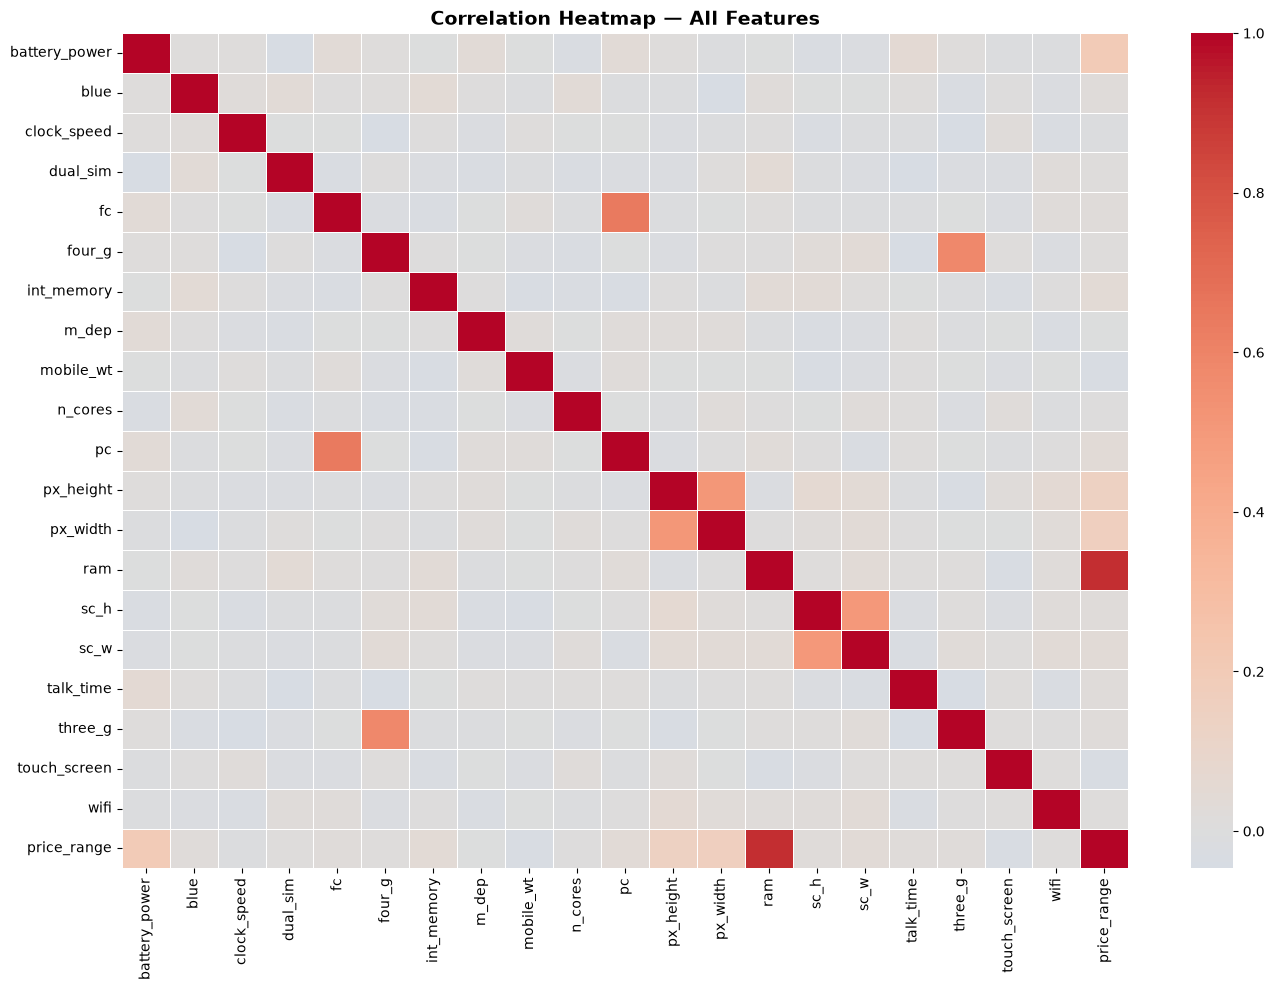

In [9]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The heatmap visually confirms the correlation ranking: the `ram`/`price_range` cell is the single darkest (strongest) non-diagonal cell in the entire matrix. A few sensible secondary relationships appear as light orange (screen height/width, front/rear camera, 3G/4G), but the overwhelming majority of the matrix is pale gray — most features are unrelated to each other or to price. This reinforces that RAM stands alone as the dominant price determinant in this dataset.

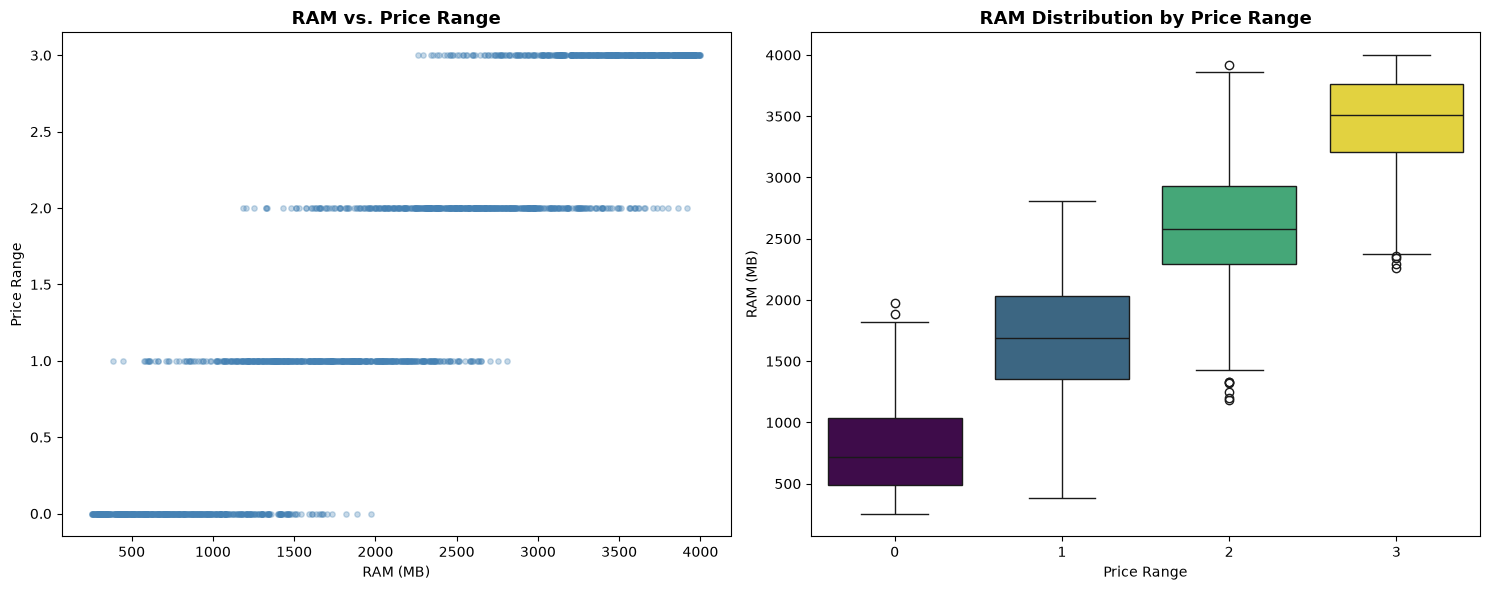

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(df['ram'], df['price_range'], alpha=0.3, color='steelblue', s=15)
axes[0].set_title('RAM vs. Price Range', fontsize=13, fontweight='bold')
axes[0].set_xlabel('RAM (MB)')
axes[0].set_ylabel('Price Range')

sns.boxplot(data=df, x='price_range', y='ram', ax=axes[1], hue='price_range', palette='viridis', legend=False)
axes[1].set_title('RAM Distribution by Price Range', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price Range')
axes[1].set_ylabel('RAM (MB)')

plt.tight_layout()
plt.show()

Both charts confirm the same striking pattern: RAM cleanly separates phones into distinct price tiers with minimal overlap. The box plot shows four price groups with almost non-overlapping RAM ranges (median RAM roughly doubling or more between each tier), and the scatter plot confirms this holds at the individual-phone level, not just as a group average. This is an unusually clean separation for real-world-style data, reinforcing that RAM functions almost as a direct proxy for price category in this dataset.

## 5. Insight Synthesis and Conclusion

### Key Findings

1. **RAM is overwhelmingly the dominant price determinant.** Correlation with price_range (r=0.917) and ANOVA (F=3520.11, p≈0) both confirm this is not a weak trend but a near-deterministic relationship — RAM alone almost perfectly sorts phones into their correct price tier, as shown by the box plot's minimal overlap between groups.

2. **Secondary factors matter far less.** Battery power (r=0.20), pixel width (r=0.17), and pixel height (r=0.15) show weak positive relationships with price — real, but in a completely different league from RAM.

3. **Most features are essentially irrelevant to price** in this dataset — connectivity features (Bluetooth, WiFi, dual SIM, 4G), processor core count, and screen dimensions all show correlations under 0.05 with price_range.

4. **The dataset's statistical shape (near-zero skewness, negative kurtosis across all features) suggests synthetic generation** for machine learning practice, rather than real-world manufacturer data — real specs would likely cluster around common industry standards rather than spread evenly.

5. **A minor data quality issue** (2 phones with `px_height = 0`, 0.10% of the dataset) was identified but determined negligible given its tiny scale.

### Unexpected Finding

The complete absence of correlation between price and expected "premium" features like 4G, dual SIM, or number of processor cores is genuinely surprising — real-world consumer intuition would suggest these connectivity/performance features drive price, but this dataset shows RAM is essentially the *only* feature that matters, with everything else contributing little to no signal.

### Conclusion

If forced to identify a single "key determinant" of mobile phone price classification in this dataset, RAM is the unambiguous answer — no other feature comes close, and the relationship is strong enough to be visually obvious in both scatter and box plot form, not just present in a correlation table.